In [146]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import pickle
from pathlib import Path

#all_trials = pd.read_parquet(Path("notebook_outputs") / "all_trials_cached.parquet")

In [147]:
# Load Q3 results before starting Q3 ashwood version

import pickle

with open("notebook_outputs/q3_workspace.pkl", "rb") as f:
    globals().update(pickle.load(f))

<!-- Q3_ASHWOOD_STYLE_BLOCK_START -->
# Q3 Ashwood-style: GLM-HMM with `ssm_new_full`

This section repeats the core Ashwood-style logic using the local `ssm_new_full` package, which mimics the original `ssm.HMM(..., observations="input_driven_obs")` API for binary-choice GLM-HMMs.

The important change from the simplified `ssm_new.SimpleGLMHMM` version is the **bias term**. In sklearn, bias is an intercept. In `ssm_new_full`, like in the original Ashwood/SSM design matrix, bias is an explicit column of ones.

So the GLM-HMM design matrix is:

```text
signed_contrast
bias = 1
previous choice
win-stay / lose-switch
```


### Q3A-1. Import `ssm_new_full`

`ssm_new_full` is a Python 3.11-compatible subset of the original `ssm` package. It supports the binary input-driven GLM-HMM path needed here.


In [148]:
# Q3 Ashwood-style import using ssm_new_full.
# This is closer to the original Ashwood-style `ssm.HMM(..., input_driven_obs)` API.

import sys
from pathlib import Path

# Use the folder where the notebook is running
project_path = Path.cwd()

if str(project_path) not in sys.path:
    sys.path.insert(0, str(project_path))

import ssm_new_full as ssm

print("ssm_new_full works")
print("Python version:", sys.version.split()[0])
print("ssm_new_full version:", getattr(ssm, "__version__", "version not found"))


ssm_new_full works
Python version: 3.11.5
ssm_new_full version: 0.1.0-glmhmm-python311


### Q3A-2. Build Ashwood-style inputs

Ashwood-style behavioral covariates are:

```text
- current stimulus
- bias
- previous choice
- win-stay / lose-switch
```


The win-stay / lose-switch regressor is computed from previous reward and previous choice:

```python
prev_choice_x_reward = prev_choice_centered * prev_reward_centered
```

`prev_reward_centered` is only used to build this regressor, one of the difference from Q3 task


We use df_q3_model because it is the clean base Q3 table with the original trial history columns.
Then we create only the Ashwood-style columns we need from it:
choice ~ signed_contrast
       + bias
       + prev_choice_centered
       + prev_choice_x_reward

yes. we have df_q3_interaction table but its sligtly different
choice ~ signed_contrast
       + prev_choice_centered
       + prev_reward_centered
       + prev_choice_x_reward

In [149]:
# Create an Ashwood-style copy from the finished Q3 data.
# This does not modify df_q3_model or the earlier Q3 result tables.

df_q3_ashwood = df_q3_model.copy(deep=True)

# Center binary history variables to -1 / +1, matching the Ashwood convention.
df_q3_ashwood['prev_choice_centered'] = (
    df_q3_ashwood['prev_choice_binary'].astype(float) * 2 - 1
)
df_q3_ashwood['prev_reward_centered'] = (
    df_q3_ashwood['prev_rewarded'].astype(float) * 2 - 1
)
df_q3_ashwood['prev_choice_x_reward'] = (
    df_q3_ashwood['prev_choice_centered']
    * df_q3_ashwood['prev_reward_centered']
)

# In ssm-style GLM-HMMs, bias is an explicit constant column.
df_q3_ashwood['bias'] = 1.0

# These are the behavioral predictors, excluding the constant bias column.
q3_ashwood_feature_columns = [
    'signed_contrast',
    'prev_choice_centered',
    'prev_choice_x_reward'
]

# This is the actual design matrix passed to ssm_new_full.
q3_ashwood_ssm_input_columns = [
    'signed_contrast',
    'bias',
    'prev_choice_centered',
    'prev_choice_x_reward'
]

q3_ashwood_required_columns = (
    q3_ashwood_ssm_input_columns
    + ['choice_binary', 'subject', 'session']
)

q3_ashwood_sort_columns = [
    col for col in ['subject', 'session_start_time', 'session', 'intervals_0']
    if col in df_q3_ashwood.columns
]

#This code removes rows with missing required values, 
# sorts trials in correct time order, and 
# makes a clean independent copy for the Ashwood-style HMM.

df_q3_ashwood = (
    df_q3_ashwood
    .dropna(subset=q3_ashwood_required_columns)
    .sort_values(q3_ashwood_sort_columns)
    .copy(deep=True)
)

#This code makes sure the choice/history columns are integers, not floats.
for col in ['choice_binary', 'prev_choice_binary', 'prev_rewarded']:
    if col in df_q3_ashwood.columns:
        df_q3_ashwood[col] = df_q3_ashwood[col].astype(int) #should be 0 or 1, so .astype(int) converts them into clean binary values for modeling.

print('Q3 Ashwood-style data shape:', df_q3_ashwood.shape)
print()
print('Behavioral predictors:', q3_ashwood_feature_columns)
print()
print('ssm_new_full design columns:', q3_ashwood_ssm_input_columns)

display(
    df_q3_ashwood[
        ['subject', 'session'] + q3_ashwood_ssm_input_columns + ['choice_binary']
    ].head()
)


Q3 Ashwood-style data shape: (2129698, 44)

Behavioral predictors: ['signed_contrast', 'prev_choice_centered', 'prev_choice_x_reward']

ssm_new_full design columns: ['signed_contrast', 'bias', 'prev_choice_centered', 'prev_choice_x_reward']


,subject,session,signed_contrast,bias,prev_choice_centered,prev_choice_x_reward,choice_binary
41825,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,0.0625,1.0,1.0,-1.0,1
41826,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,-0.1250,1.0,1.0,1.0,1
41827,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,-0.0000,1.0,1.0,-1.0,1
41828,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,-0.0000,1.0,1.0,-1.0,0
41829,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,-0.2500,1.0,-1.0,-1.0,0


### Q3A-3. Choose one long ordered session

A GLM-HMM needs ordered trials. We start with one long session containing both choices, then optionally scan several sessions later.


In [150]:
#It counts trials per subject/session and sorts sessions from longest to shortest.

q3_ashwood_session_counts = (
    df_q3_ashwood
    .groupby(['subject', 'session'])
    .size()
    .reset_index(name='n_trials')
    .sort_values('n_trials', ascending=False)
)

#It chooses the trial-time column for sorting: 
# use intervals_0 if available, otherwise use the last available sort column.

q3_ashwood_time_sort_column = (
    'intervals_0'
    if 'intervals_0' in df_q3_ashwood.columns
    else q3_ashwood_sort_columns[-1]
)

q3_ashwood_selected = None

#Этот код проходит по sessions, выбирает данные одной мыши в одной session, 
#сортирует trials по времени и делает чистую копию candidate.
#То есть candidate = one subject + one session.

for _, row in q3_ashwood_session_counts.iterrows():
    candidate = (
        df_q3_ashwood[
            (df_q3_ashwood['subject'] == row['subject'])
            & (df_q3_ashwood['session'] == row['session'])
        ]
        .sort_values(q3_ashwood_time_sort_column)
        .reset_index(drop=True)
        .copy(deep=True)
    )
#Этот код выбирает первую session, где есть оба варианта выбора (0 и 1), 
# cохраняет её как q3_ashwood_selected и останавливает поиск.
    if candidate['choice_binary'].nunique() == 2:
        q3_ashwood_selected = candidate
        break

if q3_ashwood_selected is None:
    raise ValueError('No session with both binary choices was found for the Ashwood-style GLM-HMM.')

#Этот код сохраняет имя выбранной мыши, выбранную session и сам dataframe этой session для дальнейшего GLM-HMM анализа.
q3_ashwood_subject = q3_ashwood_selected['subject'].iloc[0]
q3_ashwood_session = q3_ashwood_selected['session'].iloc[0] #.iloc[0] берёт первое значение из колонки.

q3_ashwood_session_df = q3_ashwood_selected

#Этот код берёт predictor columns для выбранной session и превращает их в NumPy matrix X типа float, 
# xтобы передать в GLM-HMM.
X_q3_ashwood = q3_ashwood_session_df[q3_ashwood_ssm_input_columns].to_numpy(dtype=float)

y_q3_ashwood = q3_ashwood_session_df['choice_binary'].to_numpy(dtype=int).reshape(-1, 1)

print('Selected subject:', q3_ashwood_subject)
print('Selected session:', q3_ashwood_session)
print('Number of trials:', len(q3_ashwood_session_df))
display(
    q3_ashwood_session_df[
        ['subject', 'session'] + q3_ashwood_ssm_input_columns + ['choice_binary']
    ].head()
)


Selected subject: ibl_witten_06
Selected session: 8d173222-0d70-4aa1-8200-7f5243f94e98
Number of trials: 1999


,subject,session,signed_contrast,bias,prev_choice_centered,prev_choice_x_reward,choice_binary
0,ibl_witten_06,8d173222-0d70-4aa1-8200-7f5243f94e98,-0.0625,1.0,1.0,-1.0,0
1,ibl_witten_06,8d173222-0d70-4aa1-8200-7f5243f94e98,-0.0000,1.0,-1.0,-1.0,1
2,ibl_witten_06,8d173222-0d70-4aa1-8200-7f5243f94e98,0.1250,1.0,1.0,-1.0,1
3,ibl_witten_06,8d173222-0d70-4aa1-8200-7f5243f94e98,1.0000,1.0,1.0,1.0,1
4,ibl_witten_06,8d173222-0d70-4aa1-8200-7f5243f94e98,-0.2500,1.0,1.0,1.0,1


### Q3A-4. Helper: fit one `ssm_new_full` GLM-HMM session

This helper uses the Ashwood-style API:

```python
ssm.HMM(
    K=3,
    D=1,
    M=4,
    observations="input_driven_obs",
    observation_kwargs={"C": 2},
    transitions="standard"
)
```

It returns state-specific GLM weights, posterior state probabilities, a transition matrix, and comparison against a 1-state logistic baseline.

Эта helper-функция обучает один Ashwood-style GLM-HMM на выбранной session: 

- 3 hidden states, 

- binary choices, 

- 4 input columns, 

- state-specific GLM weights и 

- transition matrix.

- Она также возвращает posterior state probabilities для trials и 

- сравнение с обычной 1-state logistic regression baseline.


`model.observations.weights` is the place inside the fitted GLM-HMM where the learned GLM coefficients are stored.

It is not the EM algorithm itself. It is one of the results learned after `.fit(...)`.

After EM fitting, the model stores:

- `model.observations.weights` = learned GLM weights for each hidden state

- `model.transitions` = learned transition probabilities between states

- posterior state probabilities = inferred probability of each state on each trial

So `model.observations.weights` means: what each hidden state's logistic regression learned.

In [151]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

#_sigmoid
def _sigmoid(values):
    values = np.asarray(values, dtype=float)
    return 1 / (1 + np.exp(-np.clip(values, -40, 40)))

#Эта функция достаёт GLM weights из fitted ssm model и превращает их в readable table: 
# дна строка = один hidden state, columns = weights для каждого input predictor.
def _state_parameter_table_from_ssm(model, input_columns):
    weights = model.observations.weights[:, 0, :]
    rows = []

    for state_index in range(model.K):
        row = {'state': state_index}
        for column_name, weight in zip(input_columns, weights[state_index]):
            row[f'{column_name}_weight'] = weight
        rows.append(row)

    return pd.DataFrame(rows)

#это helper для будущих plots: 
# она считает P(choice=1) отдельно для каждого hidden state, 
# используя fitted GLM weights и input matrix X.
def _predict_choice_proba_by_state_ssm(model, X):
    weights = model.observations.weights[:, 0, :]
    return _sigmoid(np.asarray(X, dtype=float) @ weights.T)

prepare X/y
fit best GLM-HMM
decode hidden states
return result tables

In [152]:
# -----------------------------
# Ashwood-style GLM-HMM settings
# -----------------------------
# These parameters control the model fit.
# We keep them outside the function so they are easy to change later.

ASHWOOD_N_STATES = 3          # Ashwood-style IBL result usually uses 3 latent states
ASHWOOD_STAY_PROBABILITY = 0.97  # encourages states to persist across trials
ASHWOOD_MAX_ITER = 80         # maximum EM iterations
ASHWOOD_RANDOM_STATE = 0      # reproducible random initialization
ASHWOOD_N_RESTARTS = 5        # fit several times and keep the best result


def fit_q3_ashwood_style_session(
    session_df,
    input_columns,
    n_states=ASHWOOD_N_STATES,
    stay_probability=ASHWOOD_STAY_PROBABILITY,
    max_iter=ASHWOOD_MAX_ITER,
    random_state=ASHWOOD_RANDOM_STATE,
    n_restarts=ASHWOOD_N_RESTARTS
):
    # -----------------------------
    # 1. Prepare X and y
    # -----------------------------
    # X contains the Ashwood-style predictors.
    # y contains the actual mouse choices.
    # GLM-HMM needs y shaped as (n_trials, 1).

    session_df = session_df.reset_index(drop=True).copy(deep=True)

    X = session_df[input_columns].to_numpy(dtype=float)

    y_vector = session_df['choice_binary'].to_numpy(dtype=int)
    y = y_vector.reshape(-1, 1)

    # -----------------------------
    # 2. Basic data checks
    # -----------------------------
    # We need enough trials and both choices.
    # Logistic observations cannot be fit if y has only 0s or only 1s.

    if len(session_df) < 20:
        raise ValueError('Need at least 20 trials for a useful GLM-HMM fit.')

    if np.unique(y_vector).size < 2:
        raise ValueError('Need both choice classes 0 and 1 for logistic observations.')

    # -----------------------------
    # 3. Fit GLM-HMM with several restarts
    # -----------------------------
    # EM can depend on initialization.
    # So we fit the same model several times with different seeds
    # and keep the model with the highest final log likelihood.

    best_model = None
    best_log_likelihoods = None
    best_final_log_likelihood = -np.inf

    for restart_index in range(n_restarts):
        seed = random_state + restart_index

        candidate_model = ssm.HMM(
            K=n_states,
            D=1,
            M=len(input_columns),
            observations='input_driven_obs',
            observation_kwargs={'C': 2},
            transitions='standard',
            transition_kwargs={'stay_probability': stay_probability},
            random_state=seed
        )

        log_likelihoods = candidate_model.fit(
            [y],
            inputs=[X],
            method='em',
            num_iters=max_iter
        )

        final_log_likelihood = log_likelihoods[-1]

        if final_log_likelihood > best_final_log_likelihood:
            best_model = candidate_model
            best_log_likelihoods = log_likelihoods
            best_final_log_likelihood = final_log_likelihood

    # -----------------------------
    # 4. Infer hidden states
    # -----------------------------
    # After fitting, we ask the model:
    # "For each trial, what is the probability of each hidden state?"
    # This gives posterior state probabilities and most likely states.

    state_probabilities, expected_joints, final_log_likelihood = (
        best_model.expected_states(y, input=X)
    )

    most_likely_states = best_model.most_likely_states(y, input=X)

    decoded_df = session_df.copy(deep=True)

    for state_index in range(n_states):
        decoded_df[f'state_{state_index}_probability'] = (
            state_probabilities[:, state_index]
        )

    decoded_df['most_likely_ashwood_state'] = most_likely_states

    # -----------------------------
    # 5. Extract learned GLM-HMM parameters
    # -----------------------------
    # These are the main Ashwood-style outputs:
    # state-specific GLM weights and transition probabilities.

    state_params_df = _state_parameter_table_from_ssm(
        best_model,
        input_columns
    )

    transition_df = pd.DataFrame(
        best_model.transitions.transition_matrix,
        columns=[f'to_state_{i}' for i in range(n_states)],
        index=[f'from_state_{i}' for i in range(n_states)]
    )

    # -----------------------------
    # 6. Fit single-state logistic baseline
    # -----------------------------
    # This baseline asks:
    # "What if the mouse used only one fixed strategy?"
    # fit_intercept=False because the design matrix already includes a bias column.

    single_logistic = LogisticRegression(
        max_iter=1000,
        fit_intercept=False
    )

    single_logistic.fit(X, y_vector)

    class_1_index = list(single_logistic.classes_).index(1)
    single_p = single_logistic.predict_proba(X)[:, class_1_index]

    single_log_likelihood = (
        -log_loss(y_vector, single_p, labels=[0, 1])
        * len(y_vector)
    )

    # -----------------------------
    # 7. Compare GLM-HMM vs single logistic
    # -----------------------------
    # The GLM-HMM should explain choices better if the mouse switches strategies.
    # BIC adds a rough penalty for having more parameters.

    hmm_log_likelihood = float(final_log_likelihood)

    n_trials = len(y_vector)
    n_inputs = len(input_columns)

    single_n_params = n_inputs

    hmm_n_params = (
        n_states * n_inputs
        + n_states * (n_states - 1)
        + (n_states - 1)
    )

    comparison_df = pd.DataFrame({
        'model': [
            'single Ashwood GLM',
            f'{n_states}-state Ashwood GLM-HMM'
        ],
        'n_parameters': [
            single_n_params,
            hmm_n_params
        ],
        'in_sample_log_likelihood': [
            single_log_likelihood,
            hmm_log_likelihood
        ],
        'log_likelihood_per_trial': [
            single_log_likelihood / n_trials,
            hmm_log_likelihood / n_trials
        ],
        'BIC': [
            single_n_params * np.log(n_trials) - 2 * single_log_likelihood,
            hmm_n_params * np.log(n_trials) - 2 * hmm_log_likelihood
        ]
    })

    comparison_df['delta_vs_single_glm'] = (
        comparison_df['log_likelihood_per_trial']
        - comparison_df.loc[0, 'log_likelihood_per_trial']
    )

    comparison_df['delta_BIC_vs_single_glm'] = (
        comparison_df['BIC']
        - comparison_df.loc[0, 'BIC']
    )

    # -----------------------------
    # 8. Summarize decoded states
    # -----------------------------
    # This table describes what the model assigned to each state:
    # how many trials, choice rate, reward rate, and session fraction.

    state_summary_df = (
        decoded_df
        .groupby('most_likely_ashwood_state')
        .agg(
            n_trials=('choice_binary', 'size'),
            choice_1_rate=('choice_binary', 'mean'),
            mean_signed_contrast=('signed_contrast', 'mean'),
            prev_choice_1_rate=('prev_choice_binary', 'mean'),
            prev_reward_rate=('prev_rewarded', 'mean')
        )
        .reset_index()
        .rename(columns={'most_likely_ashwood_state': 'state'})
    )

    state_summary_df['fraction_of_session'] = (
        state_summary_df['n_trials'] / n_trials
    )

    # -----------------------------
    # 9. Count state switches
    # -----------------------------
    # This counts how often the most likely hidden state changes over time.

    state_switch_count = int(
        decoded_df['most_likely_ashwood_state']
        .diff()
        .abs()
        .fillna(0)
        .gt(0)
        .sum()
    )

    # -----------------------------
    # 10. Return all outputs
    # -----------------------------
    # The returned dictionary keeps everything needed for later plots,
    # tables, interpretation, and model comparison.

    return {
        'model': best_model,
        'single_logistic_model': single_logistic,
        'decoded_df': decoded_df,
        'state_params_df': state_params_df,
        'transition_df': transition_df,
        'comparison_df': comparison_df,
        'state_summary_df': state_summary_df,
        'state_switch_count': state_switch_count,
        'log_likelihood_history': best_log_likelihoods,
        'expected_joints': expected_joints,
        'n_restarts': n_restarts
    }

### Q3A-5. Fit the 3-state Ashwood-style GLM-HMM

This is now a closer match to the Ashwood setup: input-driven observations, stationary transitions, 3 hidden states, and an explicit bias column.


Этот код — это момент, где мы реально запускаем модель.

До этого мы только готовили данные и написали функцию.

обучи GLM-HMM на выбранной session

- model                сама обученная модель

- decoded_df           trials + hidden state для каждого trial

- state_params_df      веса каждого state

- transition_df        вероятности перехода между states

- comparison_df        сравнение с обычной logistic regression

- state_summary_df     summary по states

In [154]:
q3_ashwood_fit = fit_q3_ashwood_style_session(
    q3_ashwood_session_df,
    input_columns=q3_ashwood_ssm_input_columns,
    n_states=3,
    stay_probability=0.97,
    max_iter=80,
    random_state=0,
    n_restarts=5
)

q3_ashwood_glm_hmm = q3_ashwood_fit['model']
q3_ashwood_decoded_df = q3_ashwood_fit['decoded_df']
q3_ashwood_state_params_df = q3_ashwood_fit['state_params_df']
q3_ashwood_transition_df = q3_ashwood_fit['transition_df']
q3_ashwood_model_comparison_df = q3_ashwood_fit['comparison_df']
q3_ashwood_state_summary_df = q3_ashwood_fit['state_summary_df']

print('Finished Q3 Ashwood-style 3-state GLM-HMM fit with ssm_new_full')
print('EM iterations per restart:', len(q3_ashwood_glm_hmm.log_likelihood_history_))
print('Restarts:', q3_ashwood_fit['n_restarts'])
print('Final log likelihood:', q3_ashwood_glm_hmm.log_likelihood(q3_ashwood_session_df['choice_binary'].to_numpy(dtype=int).reshape(-1, 1), input=X_q3_ashwood))
print('Most-likely state switches:', q3_ashwood_fit['state_switch_count'])


Finished Q3 Ashwood-style 3-state GLM-HMM fit with ssm_new_full
EM iterations per restart: 80
Restarts: 5
Final log likelihood: -586.8802027744296
Most-likely state switches: 49


### Q3A-6. State-specific weights and transition matrix

Interpret the state table like Ashwood:

- large `signed_contrast_weight` means stimulus-sensitive / engaged
- large positive or negative `bias_weight` means right- or left-biased
- large `prev_choice_centered_weight` means perseveration / history dependence
- large `prev_choice_x_reward_weight` means win-stay / lose-switch-like history
- large diagonal transition probabilities mean states persist across trials


In [155]:
display(q3_ashwood_state_params_df)
display(q3_ashwood_transition_df)
display(q3_ashwood_state_summary_df)


,state,signed_contrast_weight,bias_weight,prev_choice_centered_weight,prev_choice_x_reward_weight
0,0,4.443388,2.199544,0.255379,0.810115
1,1,17.275675,0.174518,0.980785,0.192529
2,2,2.117477,-3.661117,-0.897405,1.045371


,to_state_0,to_state_1,to_state_2
from_state_0,9.322758e-01,0.067724,8.138395e-12
from_state_1,6.554451e-03,0.965748,2.769721e-02
from_state_2,1.000000e-12,0.133194,8.668065e-01


,state,n_trials,choice_1_rate,mean_signed_contrast,prev_choice_1_rate,prev_reward_rate,fraction_of_session
0,0,87,0.885057,0.123563,0.873563,0.735632,0.043522
1,1,1713,0.523059,0.003357,0.517221,0.869819,0.856928
2,2,199,0.065327,-0.048681,0.125628,0.713568,0.099550


### Q3A-7. EM learning curve

The log likelihood should generally increase or flatten as EM improves the GLM-HMM fit.


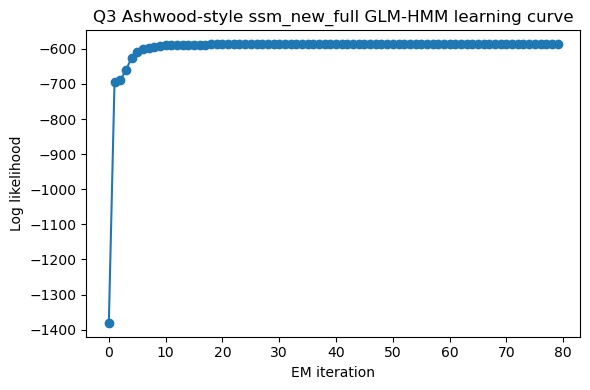

In [156]:
plt.figure(figsize=(6, 4))
plt.plot(q3_ashwood_fit['log_likelihood_history'], marker='o')
plt.xlabel('EM iteration')
plt.ylabel('Log likelihood')
plt.title('Q3 Ashwood-style ssm_new_full GLM-HMM learning curve')
plt.tight_layout()
plt.show()


### Q3A-8. Hidden state probabilities over trials

This plot shows the posterior probability of each hidden state on each ordered trial.


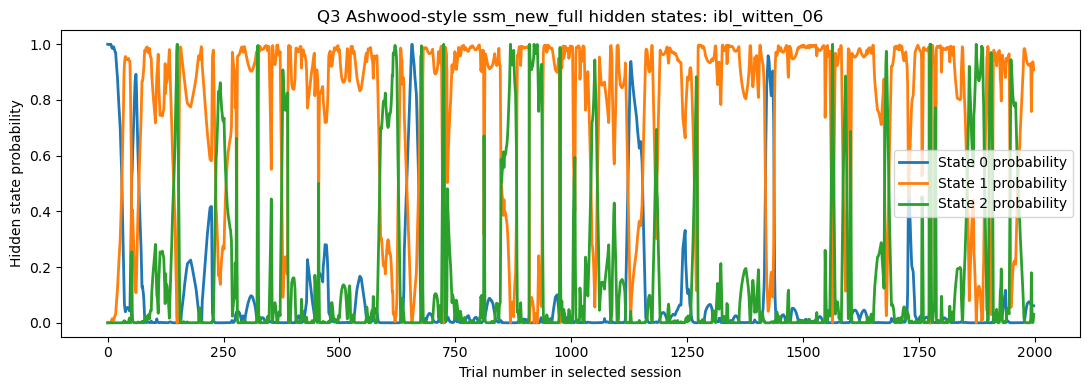

In [157]:
plt.figure(figsize=(11, 4))
for state_index in range(q3_ashwood_glm_hmm.K):
    plt.plot(
        q3_ashwood_decoded_df.index,
        q3_ashwood_decoded_df[f'state_{state_index}_probability'],
        linewidth=2,
        label=f'State {state_index} probability'
    )

plt.xlabel('Trial number in selected session')
plt.ylabel('Hidden state probability')
plt.title(f'Q3 Ashwood-style ssm_new_full hidden states: {q3_ashwood_subject}')
plt.legend()
plt.tight_layout()
plt.show()


### Q3A-9. State-specific psychometric curves

History variables are held at neutral values, and bias is held at 1. The curves show each state's contrast-to-choice mapping.


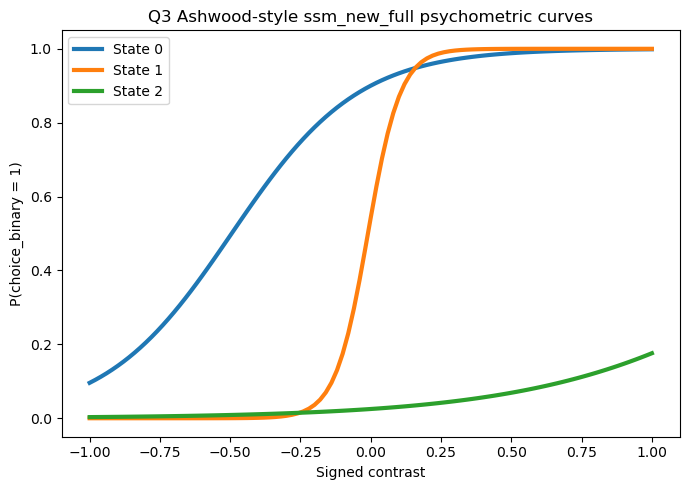

In [158]:
q3_ashwood_contrast_grid = np.linspace(-1, 1, 101)
q3_ashwood_curve_df = pd.DataFrame({
    col: np.zeros(len(q3_ashwood_contrast_grid))
    for col in q3_ashwood_ssm_input_columns
})
q3_ashwood_curve_df['signed_contrast'] = q3_ashwood_contrast_grid
q3_ashwood_curve_df['bias'] = 1.0

X_q3_ashwood_curve = q3_ashwood_curve_df[q3_ashwood_ssm_input_columns].to_numpy(dtype=float)
q3_ashwood_state_choice_probabilities = _predict_choice_proba_by_state_ssm(
    q3_ashwood_glm_hmm,
    X_q3_ashwood_curve
)

plt.figure(figsize=(7, 5))
for state_index in range(q3_ashwood_state_choice_probabilities.shape[1]):
    plt.plot(
        q3_ashwood_contrast_grid,
        q3_ashwood_state_choice_probabilities[:, state_index],
        linewidth=3,
        label=f'State {state_index}'
    )

plt.xlabel('Signed contrast')
plt.ylabel('P(choice_binary = 1)')
plt.title('Q3 Ashwood-style ssm_new_full psychometric curves')
plt.legend()
plt.tight_layout()
plt.show()


### Q3A-10. Compare against one ordinary Ashwood GLM

The 3-state model has more parameters, so in-sample log likelihood is not enough by itself. `BIC` gives a rough complexity penalty; lower BIC is better.


In [159]:
display(q3_ashwood_model_comparison_df)

q3_ashwood_improvement_per_trial = q3_ashwood_model_comparison_df.loc[
    1, 'delta_vs_single_glm'
]
q3_ashwood_delta_bic = q3_ashwood_model_comparison_df.loc[
    1, 'delta_BIC_vs_single_glm'
]

print('Ashwood-style improvement per trial:', q3_ashwood_improvement_per_trial)
print('Ashwood-style delta BIC vs single GLM:', q3_ashwood_delta_bic)
print()

if q3_ashwood_improvement_per_trial > 0:
    print('The 3-state GLM-HMM fits this selected session better in-sample than one fixed Ashwood GLM.')
else:
    print('The 3-state GLM-HMM does not improve the in-sample fit for this selected session.')

if q3_ashwood_delta_bic < 0:
    print('After the rough BIC penalty, the Ashwood-style GLM-HMM is still preferred.')
else:
    print('After the rough BIC penalty, the simpler single-state GLM is preferred for this session.')


,model,n_parameters,in_sample_log_likelihood,log_likelihood_per_trial,BIC,delta_vs_single_glm,delta_BIC_vs_single_glm
0,single Ashwood GLM,4,-698.641773,-0.349496,1427.685156,0.000000,0.000000
1,3-state Ashwood GLM-HMM,20,-586.880203,-0.293587,1325.768452,0.055909,-101.916704


Ashwood-style improvement per trial: 0.05590873962589854
Ashwood-style delta BIC vs single GLM: -101.91670367233587

The 3-state GLM-HMM fits this selected session better in-sample than one fixed Ashwood GLM.
After the rough BIC penalty, the Ashwood-style GLM-HMM is still preferred.


### Q3A-11. Compact interpretation of the fitted states

These labels are inferred from the fitted weights. The model did not receive labels like “engaged” or “biased”; those are post-hoc interpretations.


In [160]:
def describe_q3_ashwood_states(state_params_df):
    rows = []

    for _, row in state_params_df.iterrows():
        state = int(row['state'])
        contrast_weight = row.get('signed_contrast_weight', np.nan)
        bias_weight = row.get('bias_weight', np.nan)
        prev_choice_weight = row.get('prev_choice_centered_weight', 0)
        wsls_weight = row.get('prev_choice_x_reward_weight', 0)

        weights = {
            col.replace('_weight', ''): row[col]
            for col in state_params_df.columns
            if col.endswith('_weight')
        }
        strongest_name = max(weights, key=lambda name: abs(weights[name]))
        strongest_value = weights[strongest_name]

        if pd.notna(contrast_weight) and contrast_weight == state_params_df['signed_contrast_weight'].max():
            broad_label = 'stimulus-sensitive / engaged'
        elif pd.notna(bias_weight) and bias_weight < -1:
            broad_label = 'left-biased / disengaged'
        elif pd.notna(bias_weight) and bias_weight > 1:
            broad_label = 'right-biased / disengaged'
        elif abs(prev_choice_weight) > abs(wsls_weight) and abs(prev_choice_weight) > 0.5:
            broad_label = 'history-dependent / perseverative'
        elif abs(wsls_weight) > 0.5:
            broad_label = 'win-stay / lose-switch-like'
        else:
            broad_label = 'weakly differentiated state'

        rows.append({
            'state': state,
            'suggested_label': broad_label,
            'strongest_weight': strongest_name,
            'strongest_weight_value': strongest_value,
            'signed_contrast_weight': contrast_weight,
            'bias_weight': bias_weight,
            'prev_choice_centered_weight': prev_choice_weight,
            'prev_choice_x_reward_weight': wsls_weight
        })

    return pd.DataFrame(rows)

q3_ashwood_state_interpretation_df = describe_q3_ashwood_states(
    q3_ashwood_state_params_df
)

display(q3_ashwood_state_interpretation_df)


,state,suggested_label,strongest_weight,strongest_weight_value,signed_contrast_weight,bias_weight,prev_choice_centered_weight,prev_choice_x_reward_weight
0,0,right-biased / disengaged,signed_contrast,4.443388,4.443388,2.199544,0.255379,0.810115
1,1,stimulus-sensitive / engaged,signed_contrast,17.275675,17.275675,0.174518,0.980785,0.192529
2,2,left-biased / disengaged,bias,-3.661117,2.117477,-3.661117,-0.897405,1.045371


### Q3A-12. Optional: repeat the `ssm_new_full` fit across several long sessions

This gives a small project-level summary without trying to fit every session. Increase `Q3_ASHWOOD_MAX_SESSIONS` if you want a broader scan.


In [163]:
Q3_ASHWOOD_RUN_MULTI_SESSION_SCAN = True
Q3_ASHWOOD_MAX_SESSIONS = 8
Q3_ASHWOOD_MIN_TRIALS = 150

q3_ashwood_multi_session_rows = []

if Q3_ASHWOOD_RUN_MULTI_SESSION_SCAN:
    eligible_sessions = q3_ashwood_session_counts[
        q3_ashwood_session_counts['n_trials'] >= Q3_ASHWOOD_MIN_TRIALS
    ].copy()

    # Use at most one long session per subject so the summary is not dominated by one mouse.
    eligible_sessions = eligible_sessions.drop_duplicates('subject').head(Q3_ASHWOOD_MAX_SESSIONS)

    for _, row in eligible_sessions.iterrows():
        session_df = (
            df_q3_ashwood[
                (df_q3_ashwood['subject'] == row['subject'])
                & (df_q3_ashwood['session'] == row['session'])
            ]
            .sort_values(q3_ashwood_time_sort_column)
            .reset_index(drop=True)
            .copy(deep=True)
        )

        if session_df['choice_binary'].nunique() < 2:
            continue

        try:
            fit = fit_q3_ashwood_style_session(
                session_df,
                input_columns=q3_ashwood_ssm_input_columns,
                n_states=3,
                stay_probability=0.97,
                max_iter=50,
                random_state=0,
                n_restarts=3
            )
        except Exception as exc:
            q3_ashwood_multi_session_rows.append({
                'subject': row['subject'],
                'session': row['session'],
                'n_trials': len(session_df),
                'fit_status': f'failed: {exc}'
            })
            continue

        params = fit['state_params_df']
        comparison = fit['comparison_df']
        transition = fit['transition_df'].to_numpy(dtype=float)

        q3_ashwood_multi_session_rows.append({
            'subject': row['subject'],
            'session': row['session'],
            'n_trials': len(session_df),
            'fit_status': 'ok',
            'ashwood_log_likelihood_per_trial': comparison.loc[1, 'log_likelihood_per_trial'],
            'single_glm_log_likelihood_per_trial': comparison.loc[0, 'log_likelihood_per_trial'],
            'improvement_per_trial': comparison.loc[1, 'delta_vs_single_glm'],
            'delta_BIC_vs_single_glm': comparison.loc[1, 'delta_BIC_vs_single_glm'],
            'mean_self_transition_probability': np.diag(transition).mean(),
            'state_switch_count': fit['state_switch_count'],
            'contrast_weight_range': (
                params['signed_contrast_weight'].max()
                - params['signed_contrast_weight'].min()
            ),
            'bias_weight_range': (
                params['bias_weight'].max()
                - params['bias_weight'].min()
            )
        })

q3_ashwood_multi_session_df = pd.DataFrame(q3_ashwood_multi_session_rows)

display(q3_ashwood_multi_session_df)

if not q3_ashwood_multi_session_df.empty and 'improvement_per_trial' in q3_ashwood_multi_session_df.columns:
    ok_rows = q3_ashwood_multi_session_df['fit_status'].eq('ok')
    print('Successful fits:', int(ok_rows.sum()), '/', len(q3_ashwood_multi_session_df))
    print('Mean improvement per trial:', q3_ashwood_multi_session_df.loc[ok_rows, 'improvement_per_trial'].mean())
    print('Sessions with better in-sample GLM-HMM:', int((q3_ashwood_multi_session_df.loc[ok_rows, 'improvement_per_trial'] > 0).sum()))


,subject,session,n_trials,fit_status,ashwood_log_likelihood_per_trial,single_glm_log_likelihood_per_trial,improvement_per_trial,delta_BIC_vs_single_glm,mean_self_transition_probability,state_switch_count,contrast_weight_range,bias_weight_range
0,ibl_witten_06,8d173222-0d70-4aa1-8200-7f5243f94e98,1999,ok,-0.293618,-0.349496,0.055877,-101.790802,0.919846,49,15.467375,5.369614
1,ibl_witten_04,e2b571f6-3a7c-4ec1-84ba-9848e8e1ed05,1593,ok,-0.392519,-0.445463,0.052944,-50.706336,0.900898,38,20.034409,4.046937
2,CSHL_005,535e144e-0c9c-4b06-82c4-e2c92464e470,1510,ok,-0.212170,-0.279269,0.067099,-85.522636,0.973706,29,6.964116,12.016899
3,SWC_021,bddf25ed-d0e6-404f-a444-62da057f1a6d,1472,ok,-0.400259,-0.467556,0.067298,-81.413833,0.930594,44,12.443699,5.150277
4,CSHL_002,70f667a3-2eaf-47b6-ae8a-ebe121996838,1438,ok,-0.440123,-0.483771,0.043648,-9.194864,0.892961,42,10.910190,2.325268
5,CSH_ZAD_022,8db36de1-8f17-4446-b527-b5d91909b45a,1437,ok,-0.328907,-0.403054,0.074148,-96.775812,0.854791,67,129.928732,7.784100
6,ibl_witten_12,6a279108-79e0-4203-9ef6-5c6169fb1efa,1430,ok,-0.227922,-0.273229,0.045307,-13.330473,0.947043,22,56.920329,2.472642
7,ibl_witten_15,a9cad646-0491-4f63-bb16-a194c5099659,1415,ok,-0.354165,-0.421954,0.067788,-75.761985,0.931092,53,10.140082,5.352193


Successful fits: 8 / 8
Mean improvement per trial: 0.05926360954359799
Sessions with better in-sample GLM-HMM: 8


### Q3A-13. Save lightweight Ashwood-style outputs

This saves the main tables and decoded selected session. It intentionally does not save the full `all_trials` object, so the output stays small.


In [164]:
from pathlib import Path
import pickle

Path('notebook_outputs').mkdir(exist_ok=True)

q3_ashwood_output_bundle = {
    'subject': q3_ashwood_subject,
    'session': q3_ashwood_session,
    'feature_columns': q3_ashwood_feature_columns,
    'ssm_input_columns': q3_ashwood_ssm_input_columns,
    'state_params_df': q3_ashwood_state_params_df,
    'transition_df': q3_ashwood_transition_df,
    'state_summary_df': q3_ashwood_state_summary_df,
    'model_comparison_df': q3_ashwood_model_comparison_df,
    'state_interpretation_df': q3_ashwood_state_interpretation_df,
    'decoded_session_df': q3_ashwood_decoded_df,
    'multi_session_df': q3_ashwood_multi_session_df
}

with open('notebook_outputs/q3_ashwood_style_outputs.pkl', 'wb') as f:
    pickle.dump(q3_ashwood_output_bundle, f)

print('Saved Q3 Ashwood-style outputs to notebook_outputs/q3_ashwood_style_outputs.pkl')


Saved Q3 Ashwood-style outputs to notebook_outputs/q3_ashwood_style_outputs.pkl


<!-- Q3_ASHWOOD_STYLE_BLOCK_END -->


#Q3 MY NOTES

**Lose-shift** значит:  

  если мышь **не получила reward**, она на следующем trial **меняет сторону**.

- Для этого нужны 3 колонки:

  - `prev_choice_binary` = что выбрала мышь на прошлом trial

  - `prev_rewarded` = получила ли reward на прошлом trial

  - `choice_binary` = что выбрала сейчас

- Мы проверяем:
  - прошлый trial был **not rewarded**

  - текущий choice **не такой**, как previous choice

- Если оба условия true:

```text
lose-shift-like behavior
```

- Пример:

| previous choice | previous reward | current choice | meaning |
|---|---|---|---|
| left | no reward | right | lose-shift |
| right | no reward | left | lose-shift |
| left | reward | left | win-stay |
| right | reward | right | win-stay |




```text
Lose-shift-like behavior means that after an unrewarded trial, the mouse switches to the opposite choice on the next trial.
```